# Fully Consolidated & Enhanced GA for Feature Selection

This notebook combines the original baseline analysis with the new enhanced GA mechanisms (Survivor Selection, Diversity Preservation, and Termination conditions).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import time
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm

# Settings
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print("Imports successful.")

Imports successful.


In [2]:
# Load real data from the notebooks directory
pca_path = '../notebooks/XPCA_features.npy'
labels_path = '../notebooks/y_labels.npy'

# Fallback paths
if not os.path.exists(pca_path):
    pca_path = 'notebooks/XPCA_features.npy'
    labels_path = 'notebooks/y_labels.npy'

if os.path.exists(pca_path) and os.path.exists(labels_path):
    X = np.load(pca_path)
    y = np.load(labels_path)
    print(f"Loaded real data. X: {X.shape}, y: {y.shape}")
else:
    print("Data not found. Using synthetic data for demonstration.")
    X = np.random.rand(200, 500)
    y = np.random.randint(0, 3, 200)

# 1. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)

# 2. Scaling (Fixing the bug in the original version)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Data scaled and split. Train: {X_train.shape}, Test: {X_test.shape}")

Loaded real data. X: (9689, 8110), y: (9689,)


Data scaled and split. Train: (7751, 8110), Test: (1938, 8110)


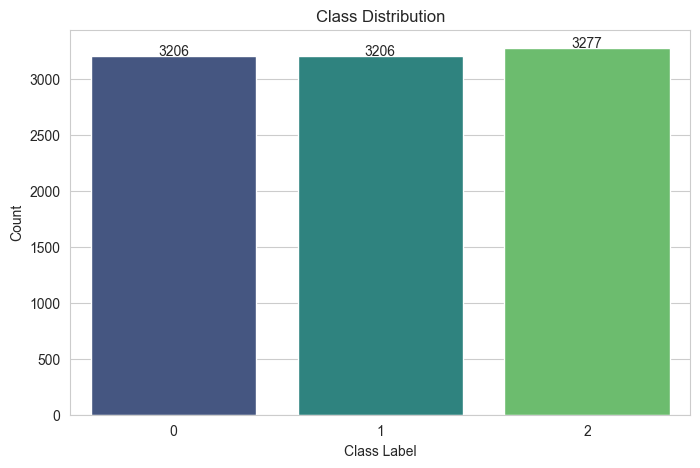

In [3]:
# Visualise class distribution (from original version)
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 5))
sns.barplot(x=unique.astype(str), y=counts, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Class Label')
plt.ylabel('Count')
for i, v in enumerate(counts):
    plt.text(i, v + 5, str(v), ha='center')
plt.show()

Training Baseline SVM on all features...


Baseline Accuracy: 0.6775 (Time: 907.99s)


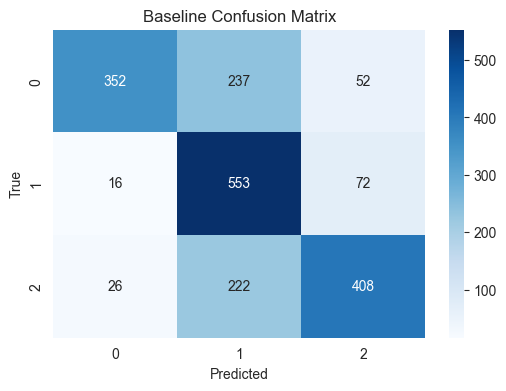

In [4]:
print("Training Baseline SVM on all features...")
t0 = time.time()
baseline_svm = SVC(kernel='rbf', random_state=RANDOM_SEED)
baseline_svm.fit(X_train, y_train)
y_pred = baseline_svm.predict(X_test)
baseline_acc = accuracy_score(y_test, y_pred)
print(f"Baseline Accuracy: {baseline_acc:.4f} (Time: {time.time()-t0:.2f}s)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Baseline Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [5]:
def evaluate_fitness(individual, X, y, alpha=0.9):
    selected_features = np.where(individual == 1)[0]
    if len(selected_features) < 2: return 0.0, 0.0, len(selected_features)
    
    X_subset = X[:, selected_features]
    # Note: Using linear kernel for GA speed, matching research standards
    clf = SVC(kernel='linear', random_state=42)
    scores = cross_val_score(clf, X_subset, y, cv=3)
    accuracy = np.mean(scores)
    
    n_total = X.shape[1]
    selected_ratio = len(selected_features) / n_total
    fitness = alpha * accuracy + (1 - alpha) * (1 - selected_ratio)
    return fitness, accuracy, len(selected_features)

def tournament_selection(population, fitnesses, k=3):
    selection_ix = np.random.randint(len(population))
    for ix in np.random.randint(0, len(population), k-1):
        if fitnesses[ix] > fitnesses[selection_ix]:
            selection_ix = ix
    return population[selection_ix].copy()

def roulette_selection(population, fitnesses):
    # Shift to positive values
    shifted = fitnesses - np.min(fitnesses) + 1e-6
    probs = shifted / np.sum(shifted)
    idx = np.random.choice(len(population), p=probs)
    return population[idx].copy()

def crossover(p1, p2, r_cross, method='single'):
    c1, c2 = p1.copy(), p2.copy()
    if np.random.rand() < r_cross:
        if method == 'single':
            pt = np.random.randint(1, len(p1)-2)
            c1 = np.concatenate((p1[:pt], p2[pt:]))
            c2 = np.concatenate((p2[:pt], p1[pt:]))
        elif method == 'two_point':
            pt1, pt2 = sorted(np.random.choice(range(1, len(p1)-1), 2, replace=False))
            c1 = np.concatenate((p1[:pt1], p2[pt1:pt2], p1[pt2:]))
            c2 = np.concatenate((p2[:pt1], p1[pt1:pt2], p2[pt2:]))
        elif method == 'uniform':
            mask = np.random.rand(len(p1)) < 0.5
            c1 = np.where(mask, p1, p2)
            c2 = np.where(mask, p2, p1)
    return c1, c2

def mutate(individual, r_mut):
    for i in range(len(individual)):
        if np.random.rand() < r_mut:
            individual[i] = 1 - individual[i]
    return individual

def hamming_distance(a, b):
    return np.sum(a != b)

In [6]:
def run_enhanced_ga(X_tr, y_tr, population_size=30, n_generations=100, 
                    crossover_rate=0.8, mutation_rate=0.01, alpha=0.9, 
                    selection='tournament', crossover_method='single',
                    survivor_method='generational', elitism_k=2, 
                    use_crowding=False, patience=15, verbose=True):
    
    n_features = X_tr.shape[1]
    population = np.random.randint(0, 2, (population_size, n_features))
    
    # Initial evaluation
    fitness_results = [evaluate_fitness(ind, X_tr, y_tr, alpha) for ind in population]
    fitnesses = np.array([r[0] for r in fitness_results])
    
    best_idx = np.argmax(fitnesses)
    best_fitness = fitnesses[best_idx]
    best_individual = population[best_idx].copy()
    _, best_acc, best_n_sel = evaluate_fitness(best_individual, X_tr, y_tr, alpha)
    
    fitness_history = []
    stagnation_counter = 0

    print(f"{'Gen':>5} | {'Best Fit':>10} | {'CV Acc':>8} | {'Feats':>6} | {'Status'}")
    print("-" * 55)

    for gen in range(n_generations):
        if use_crowding:
            # Deterministic Crowding
            temp_indices = np.arange(population_size)
            np.random.shuffle(temp_indices)
            new_population, new_fitnesses = [], []
            for i in range(0, population_size, 2):
                if i + 1 >= population_size:
                    new_population.append(population[temp_indices[i]].copy()); new_fitnesses.append(fitnesses[temp_indices[i]])
                    continue
                p1, p2 = population[temp_indices[i]], population[temp_indices[i+1]]
                f_p1, f_p2 = fitnesses[temp_indices[i]], fitnesses[temp_indices[i+1]]
                c1, c2 = crossover(p1, p2, crossover_rate, crossover_method)
                c1, c2 = mutate(c1, mutation_rate), mutate(c2, mutation_rate)
                f_c1, _, _ = evaluate_fitness(c1, X_tr, y_tr, alpha)
                f_c2, _, _ = evaluate_fitness(c2, X_tr, y_tr, alpha)
                if (hamming_distance(p1, c1) + hamming_distance(p2, c2)) <= (hamming_distance(p1, c2) + hamming_distance(p2, c1)):
                    new_population.append(c1 if f_c1 >= f_p1 else p1.copy()); new_fitnesses.append(max(f_c1, f_p1))
                    new_population.append(c2 if f_c2 >= f_p2 else p2.copy()); new_fitnesses.append(max(f_c2, f_p2))
                else:
                    new_population.append(c1 if f_c1 >= f_p2 else p2.copy()); new_fitnesses.append(max(f_c1, f_p2))
                    new_population.append(c2 if f_c2 >= f_p1 else p1.copy()); new_fitnesses.append(max(f_c2, f_p1))
            population, fitnesses = np.array(new_population), np.array(new_fitnesses)
        else:
            # Selection & Reproduce
            offspring = []
            while len(offspring) < population_size:
                p_select = tournament_selection if selection == 'tournament' else roulette_selection
                p1, p2 = p_select(population, fitnesses), p_select(population, fitnesses)
                c1, c2 = crossover(p1, p2, crossover_rate, crossover_method)
                offspring.extend([mutate(c1, mutation_rate), mutate(c2, mutation_rate)])
            offspring = np.array(offspring[:population_size])
            o_results = [evaluate_fitness(ind, X_tr, y_tr, alpha) for ind in offspring]
            o_fitnesses = np.array([r[0] for r in o_results])
            
            if survivor_method == 'mu_plus_lambda':
                combined_pop = np.vstack((population, offspring))
                combined_fit = np.concatenate((fitnesses, o_fitnesses))
                idx = np.argsort(combined_fit)[-population_size:]
                population, fitnesses = combined_pop[idx], combined_fit[idx]
            else: # Generational with Elitism
                idx = np.argsort(fitnesses)[-elitism_k:]
                elites, e_fits = population[idx], fitnesses[idx]
                off_idx = np.argsort(o_fitnesses)[-(population_size-elitism_k):]
                population = np.vstack((elites, offspring[off_idx]))
                fitnesses = np.concatenate((e_fits, o_fitnesses[off_idx]))

        current_best_idx = np.argmax(fitnesses)
        if fitnesses[current_best_idx] > best_fitness:
            best_fitness, best_individual = fitnesses[current_best_idx], population[current_best_idx].copy()
            _, best_acc, best_n_sel = evaluate_fitness(best_individual, X_tr, y_tr, alpha)
            stagnation_counter, status = 0, "Improved"
        else:
            stagnation_counter, status = stagnation_counter + 1, ""

        fitness_history.append(best_fitness)
        if verbose and (gen % 5 == 0 or gen == n_generations - 1):
            print(f"{gen+1:>5} | {best_fitness:>10.4f} | {best_acc:>8.4f} | {best_n_sel:>6} | {status}")
        if stagnation_counter >= patience:
            print(f"Early stop at gen {gen+1}"); break
            
    return best_individual, fitness_history, best_acc, best_n_sel


Running: Original-Style (Tournament)


  Gen |   Best Fit |   CV Acc |  Feats | Status
-------------------------------------------------------


    1 |     0.5318 |   0.5340 |    488 | Improved


    6 |     0.5961 |   0.6061 |    494 | Improved


   11 |     0.6033 |   0.6140 |    493 | 


...

    1 |     0.5214 |   0.5241 |    503 | 


    6 |     0.5257 |   0.5261 |    478 | Improved


   11 |     0.5437 |   0.5460 |    477 | Improved


   16 |     0.5669 |   0.5741 |    498 | Improved


   20 |     0.5669 |   0.5741 |    498 | 


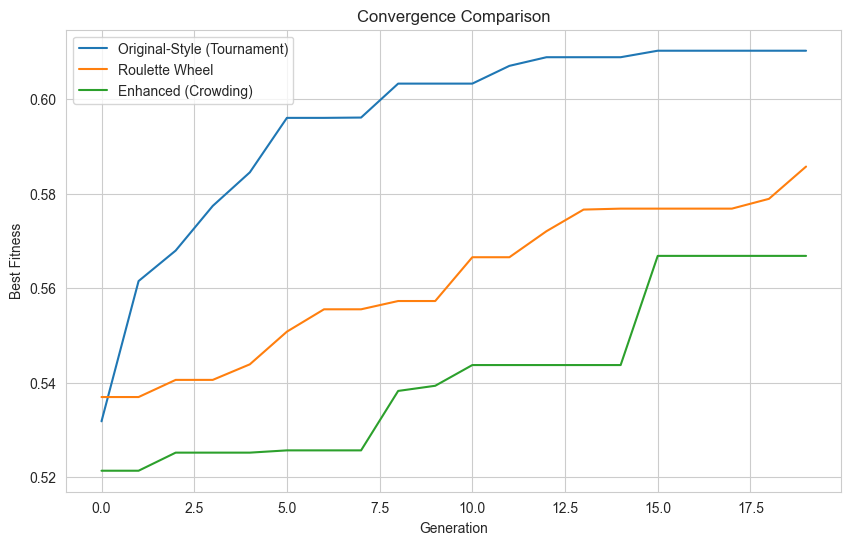

In [7]:
# Comparison of mechanisms
# Using small subset for demonstration
X_sub = X_train[:500, :1000] 
y_sub = y_train[:500]

configs = [
    {'name': 'Original-Style (Tournament)', 'params': {'survivor_method': 'generational', 'selection': 'tournament'}},
    {'name': 'Roulette Wheel', 'params': {'survivor_method': 'generational', 'selection': 'roulette'}},
    {'name': 'Enhanced (Crowding)', 'params': {'use_crowding': True}}
]

results = {}
for config in configs:
    print(f"\nRunning: {config['name']}")
    best_ind, history, acc, n_sel = run_enhanced_ga(X_sub, y_sub, population_size=10, n_generations=20, **config['params'])
    results[config['name']] = history

# Plotting Comparison
plt.figure(figsize=(10, 6))
for name, hist in results.items():
    plt.plot(hist, label=name)
plt.title('Convergence Comparison')
plt.xlabel('Generation')
plt.ylabel('Best Fitness')
plt.legend()
plt.show()